In [14]:
# Phase 1: Environment Setup & Data Ingestion
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

In [15]:
# Load the dataset
# Ensure 'future_jobs_dataset.csv' is uploaded to your Colab environment
try:
    df = pd.read_csv('future_jobs_dataset.csv')
    print("Dataset loaded successfully! Total rows:", len(df))
except FileNotFoundError:
    print("Error: Please upload the future_jobs_dataset.csv file to Colab.")

Dataset loaded successfully! Total rows: 10000


In [16]:
# Phase 2: Data Preprocessing & Feature Engineering
# 1. Isolate the Green Technology Industry
green_df = df[df['industry'] == 'Green Tech'].copy()
# Note: The dataset uses 'Green Tech' as the label for this industry
print(f"Filtered Green Tech jobs: {len(green_df)} rows")

Filtered Green Tech jobs: 2490 rows


In [17]:
# 2. Handle Missing Values (Imputation)
# Imputing numerical column (salary_usd) with median
if green_df['salary_usd'].isnull().sum() > 0:
    median_salary = green_df['salary_usd'].median()
    green_df['salary_usd'].fillna(median_salary, inplace=True)

# 3. Feature Engineering: Parsing the 'skills_required' string array
# This splits the comma-separated skills and creates binary columns for each skill
#Yeh string ko todkar har skill ke liye ek naya column bana dega (jaise Climate Data Analysis, Energy Modeling) aur agar us job mein wo skill maangi gayi hai toh wahan 1 likh dega, warna 0
skills_dummies = green_df['skills_required'].str.get_dummies(sep=', ')
green_df = pd.concat([green_df, skills_dummies], axis=1)

In [18]:
# 4. Categorical Encoding
# Convert 'remote_option' from Yes/No to 1/0
green_df['remote_option'] = green_df['remote_option'].map({'Yes': 1, 'No': 0})

# Ordinal encoding for 'company_size'
size_mapping = {'Small': 1, 'Medium': 2, 'Large': 3}
green_df['company_size'] = green_df['company_size'].map(size_mapping)

# Drop columns that are no longer needed for modeling or have been encoded
green_df.drop(columns=['job_id', 'industry', 'skills_required', 'posting_date'], inplace=True, errors='ignore')

In [19]:
# Display the cleaned and engineered dataframe
print("\nData Preprocessing Complete. Engineered dataset:")
display(green_df.head())


Data Preprocessing Complete. Engineered dataset:


,job_title,location,salary_usd,remote_option,company_size,Climate Data Analysis,Energy Modeling
1,Renewable Energy Engineer,Singapore,137481,1,3,1,1
3,Sustainability Analyst,Singapore,113822,0,3,1,1
6,Renewable Energy Engineer,New York,99659,0,1,1,1
8,Sustainability Analyst,New York,189475,0,1,1,1
16,Renewable Energy Engineer,London,214393,1,1,1,1


In [20]:
# Phase 3: Exploratory Data Analysis (EDA)
import matplotlib.pyplot as plt
import seaborn as sns
# Set the visual style for the plots
sns.set_theme(style="whitegrid")
plt.figure(figsize=(16, 12))

<Figure size 1600x1200 with 0 Axes>

<Figure size 1600x1200 with 0 Axes>

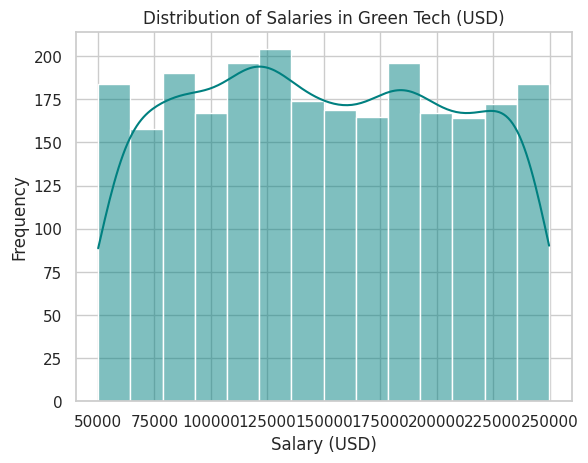

In [21]:
# Plot 1: Salary Distribution in Green Tech
sns.histplot(green_df['salary_usd'], kde=True, color='teal')
plt.title('Distribution of Salaries in Green Tech (USD)')
plt.xlabel('Salary (USD)')
plt.ylabel('Frequency')
plt.show()

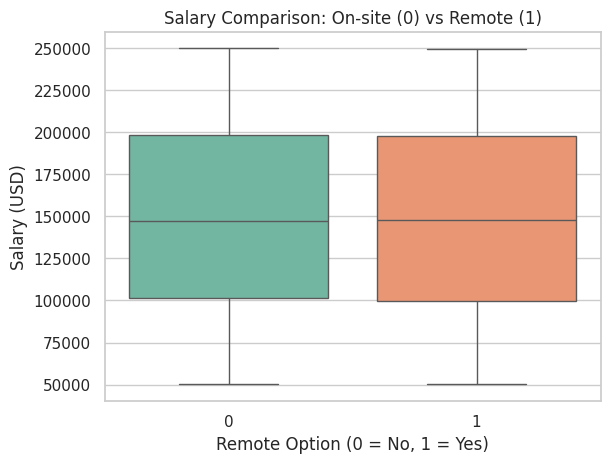

In [22]:
# Plot 2: Remote vs On-site Salary Comparison
sns.boxplot(x='remote_option', y='salary_usd', data=green_df, palette='Set2')
plt.title('Salary Comparison: On-site (0) vs Remote (1)')
plt.xlabel('Remote Option (0 = No, 1 = Yes)')
plt.ylabel('Salary (USD)')
plt.show()

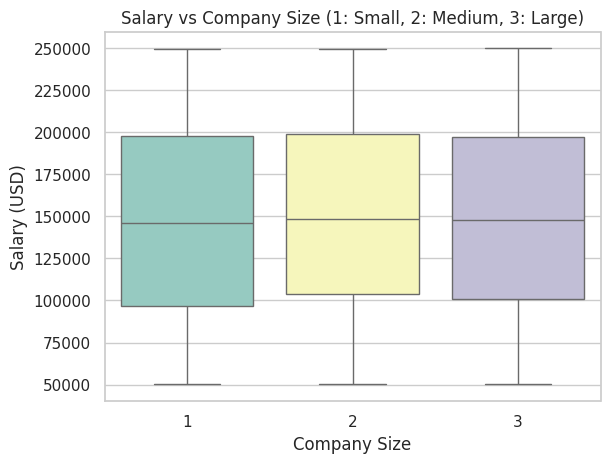

In [23]:
# Plot 3: Company Size vs Salary Comparison
sns.boxplot(x='company_size', y='salary_usd', data=green_df, palette='Set3')
plt.title('Salary vs Company Size (1: Small, 2: Medium, 3: Large)')
plt.xlabel('Company Size')
plt.ylabel('Salary (USD)')
plt.show()

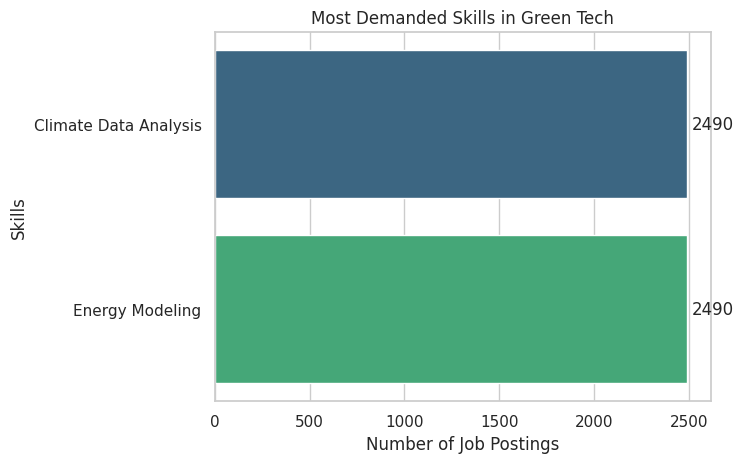

In [27]:
# Plot 4: Top Demanded Skills in Green Tech
# Identify skill columns (all columns except the original structured ones)
base_cols = ['job_title', 'location', 'salary_usd', 'remote_option', 'company_size']

# skill_cols = []
# for col in green_df.columns:
#     if col not in base_cols:
#         skill_cols.append(col)
skill_cols = [col for col in green_df.columns if col not in base_cols]

skill_counts = green_df[skill_cols].sum().sort_values(ascending=False).head(5)

# Storing the plot in a variable 'ax'
ax = sns.barplot(x=skill_counts.values, y=skill_counts.index, palette='viridis')

# Adding the exact numbers at the end of each bar using a loop
for container in ax.containers:
    ax.bar_label(container, padding=3)

plt.title('Most Demanded Skills in Green Tech')
plt.xlabel('Number of Job Postings')
plt.ylabel('Skills')
plt.show()

In [25]:
print(green_df.columns)

Index(['job_title', 'location', 'salary_usd', 'remote_option', 'company_size',
       'Climate Data Analysis', 'Energy Modeling'],
      dtype='object')


In [26]:
# Phase 4: Predictive Modeling (Machine Learning)

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
import math
import pandas as pd

# Step 1: Text columns ko numbers mein convert karna
# ML models strings nahi padh sakte. Isliye 'job_title' aur 'location' ko 1/0 (dummy columns) mein badalna zaroori hai.
ml_df = pd.get_dummies(green_df, columns=['job_title', 'location'], drop_first=True)

# Step 2: X (Features) aur y (Target) alag karna
y = ml_df['salary_usd']                  # Jise predict karna hai (Salary)
X = ml_df.drop('salary_usd', axis=1)     # Jiske basis par predict karna hai (Baki sab)

# Step 3: Data ko Train aur Test sets mein todna (80% training, 20% testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Step 4: Model ko bulana aur Train karna
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)           # Model is step mein data se seekh raha hai

# Step 5: Test data par prediction karna aur check karna model kitna sahi hai
predictions = rf_model.predict(X_test)

# Evaluation Metrics nikalna
rmse = math.sqrt(mean_squared_error(y_test, predictions))
r2 = r2_score(y_test, predictions)

print("--- Model Evaluation Results ---")
print(f"Root Mean Squared Error (RMSE): ${rmse:,.2f}")
print(f"R-squared Score: {r2:.4f}")

--- Model Evaluation Results ---
Root Mean Squared Error (RMSE): $56,487.25
R-squared Score: -0.0114
